# Jaws Segmentation 
A neural network using pytorch which segments upper (Maxilla) and lower(Mandible) jaws in a DICOM file

The Dataset is provided as 2D slices from all 3 orthogonal points of view Axial, Coronal, and Sagittal, if you're not familiar with what a DICOM is, you're expected to read online about it


In [1]:
! pip install --user torch torchvision matplotlib numpy progressbar wandb tqdm

  Using cached numpy-1.22.3-cp39-cp39-win_amd64.whl (14.7 MB)
  Using cached requests-2.27.1-py2.py3-none-any.whl (63 kB)
  Using cached cycler-0.11.0-py3-none-any.whl (6.4 kB)
  Using cached idna-3.3-py3-none-any.whl (61 kB)
  Using cached charset_normalizer-2.0.12-py3-none-any.whl (39 kB)
  Using cached urllib3-1.26.9-py2.py3-none-any.whl (138 kB)
  Created wheel for progressbar: filename=progressbar-2.5-py3-none-any.whl size=12082 sha256=939d07be4ec70792cde0628cd938f9fb273b0d43361da6ad84453467a72427c2
  Stored in directory: c:\users\alima\appdata\local\pip\cache\wheels\d7\d9\89\a3f31c76ff6d51dc3b1575628f59afe59e4ceae3f2748cd7ad
Successfully built progressbar


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import urllib.request
import zipfile
import os
import progressbar
from math import ceil
import torch
import gzip
import numpy as np
import glob
import matplotlib.pyplot as plt
from torchvision import transforms

import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as TF

from tqdm import tqdm # more familiar with
import logging
import wandb
from pathlib import Path
from unet import UNet
from torch import Tensor


In [3]:

AXIAL_TRAINING_DATASET = 'https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/axial/train.zip'
AXIAL_TESTING_DATASET = 'https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/axial/test.zip'
CORONAL_TRAINING_DATASET = 'https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/coronal/train.zip'
CORONAL_TESTING_DATASET = 'https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/coronal/test.zip'
SAGITTAL_TRAINING_DATASET = 'https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/sagittal/train.zip'
SAGITTAL_TESTING_DATASET = 'https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/sagittal/test.zip'


In [9]:
LOCAL_DATASET_PATH = 'dataset'
BATCH_SIZE = 16
IMAGE_HEIGHT = 160
IMAGE_WIDTH = 240
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
PIN_MEMORY = True
NUM_CLASSES = 3
NUM_WORKERS = 10
AMP = False
SAVE_CHECKPOINT = True
VAL_PERCENT = 0.1
DIR_CHECKPOINT = Path('./checkpoints/')


## Downloading Dataset

In this part we download the publicly available dataset, you can skip it if you already have it, it should be 5.6 Gb worth of data

In [8]:
download_progress_bar = None
def show_progress(block_num, block_size, total_size):
    global download_progress_bar
    if download_progress_bar is None:
        download_progress_bar = progressbar.ProgressBar(maxval=total_size)
        download_progress_bar.start()

    downloaded = block_num * block_size
    if downloaded < total_size:
        download_progress_bar.update(downloaded)
    else:
        download_progress_bar.finish()
        download_progress_bar = None

def download_file(url, disk_path):
    print(f'downloading {url}')
    filename, _ = urllib.request.urlretrieve(url, reporthook=show_progress)
    os.makedirs(disk_path)
    with zipfile.ZipFile(filename, 'r') as zip:
        zip.extractall(disk_path)

def download_data(to=LOCAL_DATASET_PATH):
    #download_file(AXIAL_TRAINING_DATASET, os.path.join(to, 'axial', 'train'))
    #download_file(AXIAL_TESTING_DATASET, os.path.join(to, 'axial', 'test'))
    download_file(CORONAL_TRAINING_DATASET, os.path.join(to, 'coronal', 'train'))
    download_file(CORONAL_TESTING_DATASET, os.path.join(to, 'coronal', 'test'))
    download_file(SAGITTAL_TRAINING_DATASET, os.path.join(to, 'sagittal', 'train'))
    download_file(SAGITTAL_TESTING_DATASET, os.path.join(to, 'sagittal', 'test'))

download_data()

downloading https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/coronal/train.zip


100% |########################################################################|


downloading https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/coronal/test.zip


100% |########################################################################|


downloading https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/sagittal/train.zip


100% |########################################################################|


downloading https://cvml-datasets.s3.eu-west-3.amazonaws.com/jaws-segmentation/v1/public/2d/sagittal/test.zip


100% |########################################################################|


## Explore The Dataset

In this section you should explore/plot the dataset and get familiar with it, we are nice enough to write a dataset loader for you and we did some initial visualization for you

In [10]:
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as TF


class JawsDataset(torch.utils.data.Dataset):
	def __init__(self, dicom_file_list, transforms):
		self.dicom_file_list = dicom_file_list
		self.transforms = transforms

	def __len__(self):
		return len(self.dicom_file_list)

	def __getitem__(self, idx):
		dicom_path = self.dicom_file_list[idx]
		label_path = dicom_path.replace('.dicom.npy.gz', '.label.npy.gz')
		dicom_file = gzip.GzipFile(dicom_path, 'rb')
		dicom = np.load(dicom_file)
		label_file = gzip.GzipFile(label_path, 'rb')
		label = np.load(label_file)
		return self.transforms(dicom), self.transforms(label)

class TrainJawsDataset(JawsDataset):
    def __init__(self, dicom_file_list, dataset_transforms):
        self.dicom_file_list = dicom_file_list
        self.dataset_transforms = dataset_transforms
        
        self.train_transforms = transforms.Compose([
            # I chose center as median point in H&W, image is set as variable
            transforms.RandomRotation(35, center=(IMAGE_HEIGHT//2, IMAGE_WIDTH//2)),
            transforms.RandomHorizontalFlip(p=0.5)
        ])
        
    def __len__(self):
        return len(self.dicom_file_list)
    
    def __getitem__(self, i):
        image, label = super(TrainJawsDataset, self).__getitem__(i)
        
        # I had an idea of automating all steps in transformations
        # put all transformations in a list of callables
        # put all args for transformations as a list of kwargs 
        # put all probabilities for corresponding transformations in a list
        # eventually, code was a little bit an overkill, I'll attach it in 
        # a separate file for reference
        
        if np.random.rand() < .7:
            angle = 35 * (np.random.rand()*2 - 1)
            
            # I chose center as median point in H&W, image is set as variable
            center = (IMAGE_HEIGHT//2, IMAGE_WIDTH//2)
            
            image = TF.rotate(image, angle, center = center)
            label = TF.rotate(label, angle, center = center)
        
        if np.random.rand() < .6:
            image = TF.hflip(image)
            label = TF.hflip(label)
            
        return image, label

def axial_dataset_train(transforms, validation_ratio = 0.1):
	files = glob.glob('dataset/axial/train/**/*.dicom.npy.gz')
	assert len(files) > 0
	validation_files_count = ceil(len(files) * validation_ratio)

	return (JawsDataset(files[validation_files_count:], transforms),
			JawsDataset(files[:validation_files_count], transforms))

def coronal_dataset_train(transforms, validation_ratio = 0.1):
	files = glob.glob('dataset/coronal/train/**/*.dicom.npy.gz')
	assert len(files) > 0
	validation_files_count = ceil(len(files) * validation_ratio)

	return (JawsDataset(files[validation_files_count:], transforms),
			JawsDataset(files[:validation_files_count], transforms))

def sagittal_dataset_train(transforms, validation_ratio = 0.1):
	files = glob.glob('dataset/sagittal/train/**/*.dicom.npy.gz')
	assert len(files) > 0
	assert len(files) > 0
	validation_files_count = ceil(len(files) * validation_ratio)

	return (JawsDataset(files[validation_files_count:], transforms),
			JawsDataset(files[:validation_files_count], transforms))

def axial_dataset_test(transforms):
	files = glob.glob('dataset/axial/test/**/*.dicom.npy.gz')
	assert len(files) > 0
	return JawsDataset(files, transforms)

def coronal_dataset_test(transforms):
	files = glob.glob('dataset/coronal/test/**/*.dicom.npy.gz')
	assert len(files) > 0
	return JawsDataset(files, transforms)

def sagittal_dataset_test(transforms):
	files = glob.glob('dataset/sagittal/test/**/*.dicom.npy.gz')
	assert len(files) > 0
	return JawsDataset(files, transforms)


In [11]:
dataset_transforms = transforms.Compose([transforms.ToTensor(), transforms.Resize((IMAGE_HEIGHT, IMAGE_WIDTH))])

In [12]:
axial_train_dataset, axial_validatiaon_dataset = axial_dataset_train(dataset_transforms)
coronal_train_dataset, coronal_validation_dataset = coronal_dataset_train(dataset_transforms)
sagittal_train_dataset, sagittal_validation_dataset = sagittal_dataset_train(dataset_transforms)
print(f'axial training dataset: {len(axial_train_dataset)} slice')
print(f'coronal training dataset: {len(coronal_train_dataset)} slice')
print(f'sagittal training dataset: {len(sagittal_train_dataset)} slice')
N_AXIAL_TRAIN =  len(axial_train_dataset)
N_AXIAL_VAL =  len(axial_validatiaon_dataset)
axial_train_loader = torch.utils.data.DataLoader(axial_train_dataset, shuffle=True, batch_size=BATCH_SIZE)
coronal_train_loader = torch.utils.data.DataLoader(coronal_train_dataset, shuffle=True, batch_size=BATCH_SIZE)
sagittal_train_loader = torch.utils.data.DataLoader(sagittal_train_dataset, shuffle=True, batch_size=BATCH_SIZE)



axial_validation_loader = torch.utils.data.DataLoader(axial_validatiaon_dataset, shuffle=True, batch_size=BATCH_SIZE)
coronal_validation_loader = torch.utils.data.DataLoader(coronal_validation_dataset, shuffle=True, batch_size=BATCH_SIZE)
sagittal_validation_loader = torch.utils.data.DataLoader(sagittal_validation_dataset, shuffle=True, batch_size=BATCH_SIZE)

axial training dataset: 5043 slice
coronal training dataset: 7277 slice
sagittal training dataset: 7277 slice


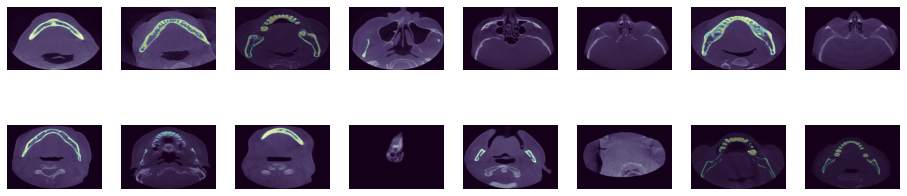

In [9]:
axial_data_iter = iter(axial_train_loader)
images, labels = axial_data_iter.next()
plt.figure(figsize=(16, 4))
for index in range(0, min(16, len(images))):
	plt.subplot(2, 8, index + 1)
	plt.axis('off')
	plt.imshow(images[index].numpy().squeeze(), cmap='bone')
	plt.imshow(labels[index].numpy().squeeze(), alpha=0.3)

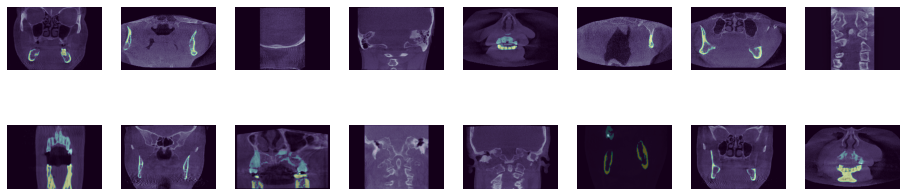

In [10]:
coronal_data_iter = iter(coronal_train_loader)
images, labels = coronal_data_iter.next()
plt.figure(figsize=(16, 4))
for index in range(0, min(16, len(images))):
	plt.subplot(2, 8, index + 1)
	plt.axis('off')
	plt.imshow(images[index].numpy().squeeze(), cmap='bone')
	plt.imshow(labels[index].numpy().squeeze(), alpha=0.3)

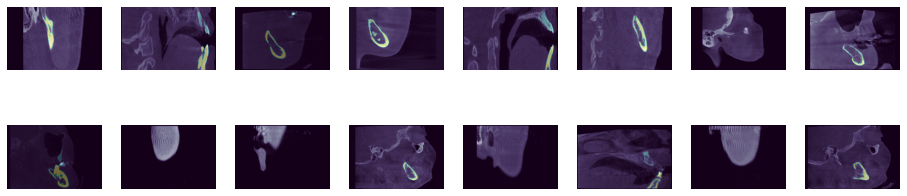

In [16]:
sagittal_data_iter = iter(sagittal_train_loader)
images, labels = sagittal_data_iter.next()
plt.figure(figsize=(16, 4))
for index in range(0, min(16, len(images))):
	plt.subplot(2, 8, index + 1)
	plt.axis('off')
	plt.imshow(images[index].numpy().squeeze(), cmap='bone')
	plt.imshow(labels[index].numpy().squeeze(), alpha=0.3)

## Training

Now that you have downloaded the dataset and inspected it for a bit, you should train your model here, you can train a single model which works with all views (axial, sagittal, coronal), or you can train a model each, it's up to you

In [11]:
train_loaders = {
    'axial': axial_train_loader,
    'coronal': coronal_train_loader,
    'sagittal': sagittal_train_loader
}

val_loaders = {
    'axial': axial_validation_loader,
    'coronal': coronal_validation_loader,
    'sagittal': sagittal_validation_loader
}

In [12]:

def dice_coeff(input: Tensor, target: Tensor, reduce_batch_first: bool = False, epsilon=1e-6):
    # Average of Dice coefficient for all batches, or for a single mask
    assert input.size() == target.size()
    if input.dim() == 2 and reduce_batch_first:
        raise ValueError(f'Dice: asked to reduce batch but got tensor without batch dimension (shape {input.shape})')

    if input.dim() == 2 or reduce_batch_first:
        inter = torch.dot(input.reshape(-1), target.reshape(-1))
        sets_sum = torch.sum(input) + torch.sum(target)
        if sets_sum.item() == 0:
            sets_sum = 2 * inter

        return (2 * inter + epsilon) / (sets_sum + epsilon)
    else:
        # compute and average metric for each batch element
        dice = 0
        for i in range(input.shape[0]):
            dice += dice_coeff(input[i, ...], target[i, ...])
        return dice / input.shape[0]
def multiclass_dice_coeff(input: Tensor, target: Tensor, reduce_batch_first: bool = False, epsilon=1e-6):
    # Average of Dice coefficient for all classes
    assert input.size() == target.size()
    dice = 0
    for channel in range(input.shape[1]):
        dice += dice_coeff(input[:, channel, ...], target[:, channel, ...], reduce_batch_first, epsilon)

    return dice / input.shape[1]

def dice_loss(input: Tensor, target: Tensor, multiclass: bool = False):
    # Dice loss (objective to minimize) between 0 and 1
    assert input.size() == target.size()
    fn = multiclass_dice_coeff if multiclass else dice_coeff
    return 1 - fn(input, target, reduce_batch_first=True)

In [13]:
def evaluate(model, dataloader, device):
    model.eval()
    num_val_batches = len(dataloader)
    dice_score = 0

    # iterate over the validation set
    for batch in tqdm(dataloader, total=num_val_batches, desc='Validation round', unit='batch', leave=False):
        image, mask_true = batch
        mask_true = mask_true.squeeze(1)
        # move images and labels to correct device and type
        image = image.to(device=device, dtype=torch.float32)
        mask_true = mask_true.to(device=device, dtype=torch.long)
        mask_true = F.one_hot(mask_true, model.n_classes).permute(0, 3, 1, 2).float()

        with torch.no_grad():
            # predict the mask
            mask_pred = model(image)

            # convert to one-hot format
            if model.n_classes == 1:
                mask_pred = (F.sigmoid(mask_pred) > 0.5).float()
                # compute the Dice score
                dice_score += dice_coeff(mask_pred, mask_true, reduce_batch_first=False)
            else:
                mask_pred = F.one_hot(mask_pred.argmax(dim=1), model.n_classes).permute(0, 3, 1, 2).float()
                # compute the Dice score, ignoring background
                dice_score += multiclass_dice_coeff(mask_pred[:, 1:, ...], mask_true[:, 1:, ...], reduce_batch_first=False)

           

    model.train()

    # Fixes a potential division by zero error
    if num_val_batches == 0:
        return dice_score
    return dice_score / num_val_batches


In [14]:
def train_net(plane):
    model = UNet(n_channels=1, n_classes=NUM_CLASSES).to(DEVICE)
    train_loader = train_loaders[plane]
    val_loader = val_loaders[plane]

    # (Initialize logging)
    experiment = wandb.init(project='U-Net', resume='allow', anonymous='must')
    experiment.config.update(dict(epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
                                  val_percent=VAL_PERCENT, save_checkpoint=SAVE_CHECKPOINT, 
                                  amp=AMP, plane = plane))

    logging.info(f'''Starting training:
        Epochs:          {NUM_EPOCHS}
        Batch size:      {BATCH_SIZE}
        Learning rate:   {LEARNING_RATE}
        Checkpoints:     {SAVE_CHECKPOINT}
        Device:          {DEVICE}
        Training size:   {N_AXIAL_TRAIN}
        Validation size: {N_AXIAL_VAL}
        plane:           {plane}
    ''')

    # 4. Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
    optimizer = torch.optim.RMSprop(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-8, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)  # goal: maximize Dice score
    grad_scaler = torch.cuda.amp.GradScaler(enabled=AMP)
    criterion = nn.CrossEntropyLoss()
    global_step = 0

    # 5. Begin training
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0
        with tqdm(total=N_AXIAL_TRAIN, desc=f'Epoch {epoch + 1}/{NUM_EPOCHS}', unit='img') as pbar:
            for batch in train_loader:
                images, true_masks = batch

                assert images.shape[1] == model.n_channels, \
                    f'Network has been defined with {model.n_channels} input channels, ' \
                    f'but loaded images have {images.shape[1]} channels. Please check that ' \
                    'the images are loaded correctly.'

                images = images.to(device=DEVICE, dtype=torch.float32)
                true_masks = true_masks.to(device=DEVICE, dtype=torch.long)

                with torch.cuda.amp.autocast(enabled=AMP):
                    masks_pred = model(images)
                    true_masks = true_masks.squeeze(1)
                    loss = criterion(masks_pred, true_masks) \
                           + dice_loss(F.softmax(masks_pred, dim=1).float(),
                                       F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float(),
                                       multiclass=True)

                optimizer.zero_grad(set_to_none=True)
                grad_scaler.scale(loss).backward()
                grad_scaler.step(optimizer)
                grad_scaler.update()

                pbar.update(images.shape[0])
                global_step += 1
                epoch_loss += loss.item()
                experiment.log({
                    'train loss': loss.item(),
                    'step': global_step,
                    'epoch': epoch
                })
                pbar.set_postfix(**{'loss (batch)': loss.item()})

                # Evaluation round
                division_step = (N_AXIAL_TRAIN // (10 * BATCH_SIZE))
                if division_step > 0:
                    if global_step % division_step == 0:
                        histograms = {}
                        for tag, value in model.named_parameters():
                            tag = tag.replace('/', '.')
                            histograms['Weights/' + tag] = wandb.Histogram(value.data.cpu())
                            histograms['Gradients/' + tag] = wandb.Histogram(value.grad.data.cpu())

                        val_score = evaluate(model, val_loader, DEVICE)
                        scheduler.step(val_score)

                        logging.info('Validation Dice score: {}'.format(val_score))
                        experiment.log({
                            'learning rate': optimizer.param_groups[0]['lr'],
                            'validation Dice': val_score,
                            'images': wandb.Image(images[0].cpu()),
                            'masks': {
                                'true': wandb.Image(true_masks[0].float().cpu()),
                                'pred': wandb.Image(torch.softmax(masks_pred, dim=1).argmax(dim=1)[0].float().cpu()),
                            },
                            'step': global_step,
                            'epoch': epoch,
                            **histograms
                        })

        if SAVE_CHECKPOINT:
            save = Path(DIR_CHECKPOINT).joinpath(plane)
            save.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), str(save) +'\\'+ 'checkpoint_epoch{}.pth'.format(epoch + 1))
            logging.info(f'Checkpoint {epoch + 1} saved!')


In [15]:
coronal_model = train_net('coronal')


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: anony-mouse-228202 (use `wandb login --relogin` to force relogin)


Epoch 1/20: 7277img [09:58, 12.15img/s, loss (batch)=0.24]                          
Epoch 2/20: 7277img [10:17, 11.78img/s, loss (batch)=0.164]                          
Epoch 3/20: 7277img [10:22, 11.69img/s, loss (batch)=0.135]                          
Epoch 4/20: 7277img [09:58, 12.17img/s, loss (batch)=0.103]                          
Epoch 5/20: 7277img [10:26, 11.62img/s, loss (batch)=0.154]                          
Epoch 6/20: 7277img [10:32, 11.51img/s, loss (batch)=0.154]                          
Epoch 7/20: 7277img [10:08, 11.96img/s, loss (batch)=0.14]                           
Epoch 8/20: 7277img [10:24, 11.65img/s, loss (batch)=0.113]                          
Epoch 9/20: 7277img [10:30, 11.55img/s, loss (batch)=0.111]                          
Epoch 10/20: 7277img [10:11, 11.90img/s, loss (batch)=0.153]                          
Epoch 11/20: 7277img [10:25, 11.64img/s, loss (batch)=0.107]                          
Epoch 12/20: 7277img [10:14, 11.85img/s, loss (batch)

In [16]:
sagittal_model = train_net('sagittal')


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
learning rate,███▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train loss,█▄▂▂▁▁▂▂▂▇▂▁▁▂▃▃▂▂▁▂▃▂▃▂▁▁▂▂▁▁▁▃▅▄▂▃▂▂▁▁
validation Dice,▁▁▅▇████████████████████████████████████
epoch,19
learning rate,0.0
step,9100
train loss,0.10802
validation Dice,0.80636


Epoch 1/20: 7277img [11:07, 10.90img/s, loss (batch)=0.133]                         
Epoch 2/20: 7277img [10:32, 11.50img/s, loss (batch)=0.155]                          
Epoch 3/20: 7277img [10:29, 11.57img/s, loss (batch)=0.142]                          
Epoch 4/20: 7277img [10:09, 11.94img/s, loss (batch)=0.091]                         
Epoch 5/20: 7277img [10:32, 11.51img/s, loss (batch)=0.212]                          
Epoch 6/20: 7277img [10:18, 11.77img/s, loss (batch)=0.151]                          
Epoch 7/20: 7277img [09:59, 12.14img/s, loss (batch)=0.17]                           
Epoch 8/20: 7277img [10:16, 11.81img/s, loss (batch)=0.133]                          
Epoch 9/20: 7277img [10:17, 11.79img/s, loss (batch)=0.126]                          
Epoch 10/20: 7277img [10:06, 12.00img/s, loss (batch)=0.133]                          
Epoch 11/20: 7277img [10:23, 11.67img/s, loss (batch)=0.149]                          
Epoch 12/20: 7277img [10:45, 11.28img/s, loss (batch)=

## Testing

Now you should run your trained model on the test dataset available below and report your results

In [13]:
axial_test_dataset = axial_dataset_test(dataset_transforms)
coronal_test_dataset = coronal_dataset_test(dataset_transforms)
sagittal_test_dataset = sagittal_dataset_test(dataset_transforms)
print(f'axial testing dataset: {len(axial_test_dataset)} slice')
print(f'coronal testing dataset: {len(coronal_test_dataset)} slice')
print(f'sagittal testing dataset: {len(sagittal_test_dataset)} slice')

axial_test_loader = torch.utils.data.DataLoader(axial_train_dataset, shuffle=True, batch_size=BATCH_SIZE)
coronal_test_loader = torch.utils.data.DataLoader(coronal_train_dataset, shuffle=True, batch_size=BATCH_SIZE)
sagittal_test_loader = torch.utils.data.DataLoader(sagittal_train_dataset, shuffle=True, batch_size=BATCH_SIZE)

axial testing dataset: 1450 slice
coronal testing dataset: 2348 slice
sagittal testing dataset: 2448 slice


In [14]:
test_loaders = {
    'axial': axial_test_loader,
    'coronal': coronal_test_loader,
    'sagittal': sagittal_test_loader
}

In [27]:
#load model for chechk point 
model_axial = UNet(n_channels=1, n_classes=3)
model_axial.to(device=DEVICE)
model_axial.load_state_dict(torch.load(os.path.join("checkpoints", "axial","checkpoint_epoch19.pth" ), map_location=DEVICE))

<All keys matched successfully>

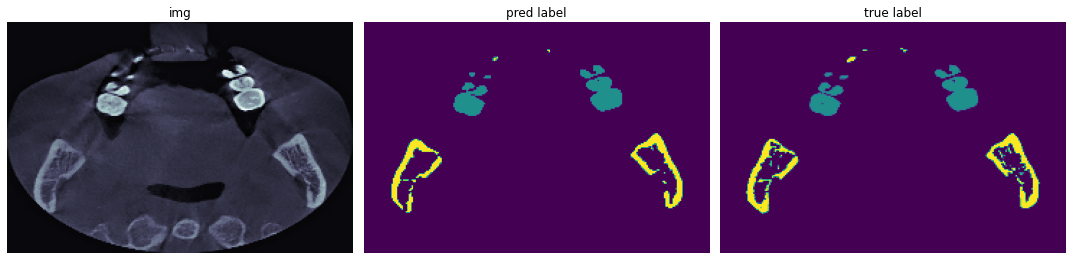

In [33]:
model_axial.eval()
plane = 'axial'
sample = iter(test_loaders[plane]).next()
sample_img = sample[0][:1]
sample_true = sample[1][:1]
full_mask = []
with torch.no_grad():
    output = model_axial(sample_img.to(DEVICE)).cpu()

    if model_axial.n_classes > 1:
        probs = F.softmax(output, dim=1)[0]
    else:
        probs = torch.sigmoid(output)[0]
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title('img')
plt.axis('off')
plt.imshow(sample_img.squeeze(), cmap='bone')

plt.subplot(1,3,2)
plt.title('pred label')
plt.axis('off')
plt.imshow(torch.argmax(probs, dim=0))

plt.subplot(1,3,3)
plt.title('true label')
plt.axis('off')
plt.imshow(sample_true.squeeze())
plt.tight_layout()



In [46]:
#load model for chechk point 
model_coronal = UNet(n_channels=1, n_classes=3)
model_coronal.to(device=DEVICE)
model_coronal.load_state_dict(torch.load(os.path.join("checkpoints", "coronal","checkpoint_epoch19.pth" ), map_location=DEVICE))

<All keys matched successfully>

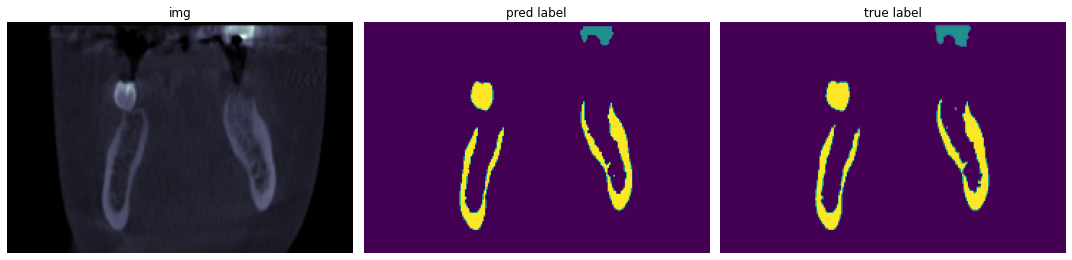

In [49]:
model_coronal.eval()
plane = 'coronal'
sample = iter(test_loaders[plane]).next()
sample_img = sample[0][:1]
sample_true = sample[1][:1]
full_mask = []
with torch.no_grad():
    output = model_coronal(sample_img.to(DEVICE)).cpu()

    if model_coronal.n_classes > 1:
        probs = F.softmax(output, dim=1)[0]
    else:
        probs = torch.sigmoid(output)[0]
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title('img')
plt.axis('off')
plt.imshow(sample_img.squeeze(), cmap='bone')

plt.subplot(1,3,2)
plt.title('pred label')
plt.axis('off')
plt.imshow(torch.argmax(probs, dim=0))

plt.subplot(1,3,3)
plt.title('true label')
plt.axis('off')
plt.imshow(sample_true.squeeze())
plt.tight_layout()

In [50]:
#load model for chechk point 
model_sagittal = UNet(n_channels=1, n_classes=3)
model_sagittal.to(device=DEVICE)
model_sagittal.load_state_dict(torch.load(os.path.join("checkpoints", "sagittal","checkpoint_epoch19.pth" ), map_location=DEVICE))

<All keys matched successfully>

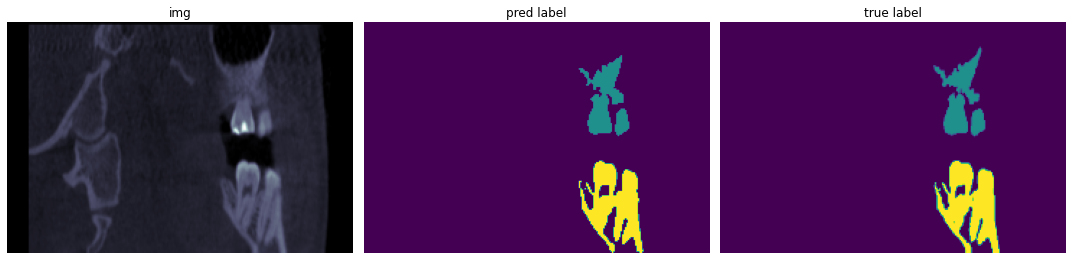

In [51]:
model_sagittal.eval()
plane = 'sagittal'
sample = iter(test_loaders[plane]).next()
sample_img = sample[0][:1]
sample_true = sample[1][:1]
full_mask = []
with torch.no_grad():
    output = model_sagittal(sample_img.to(DEVICE)).cpu()

    if model_sagittal.n_classes > 1:
        probs = F.softmax(output, dim=1)[0]
    else:
        probs = torch.sigmoid(output)[0]
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title('img')
plt.axis('off')
plt.imshow(sample_img.squeeze(), cmap='bone')

plt.subplot(1,3,2)
plt.title('pred label')
plt.axis('off')
plt.imshow(torch.argmax(probs, dim=0))

plt.subplot(1,3,3)
plt.title('true label')
plt.axis('off')
plt.imshow(sample_true.squeeze())
plt.tight_layout()

## Discussion

the Unet model with traditinal Cross Entropy Loss shows promissing results in 2D sigmantation for coronal, sagital panals 
but according to loss of knowldge that happend through sclicing of 3d image preformming this process via 3d image will be much promissing
also the objects (upper jaw , lower jaw ) appers in a small portion in the image this leads to impalance class so the Focal Loss function will be a better chois in this task 

**note**
there is some ambiguty about dataset i've didn't find any online docements about it and the information are inneed for the 3d reconstraction 